We model the following ODE driven by the El Centro Earthquake:
$$
\ddot u(t) + 2\xi\omega_n\,\dot u(t) + \omega_n^{2}u(t)
        = -9.81\,a(t),
\qquad
u(0)=\dot u(0)=0,
$$
where $a(t)$ is the normalized ground-acceleration record, $\xi$ is the damping ratio, and $\omega_n$ is the natural frequency.


In the experiment, we take:
- $\xi = 0.02$
- $T_n = 5\,\mathrm{s}$
- $\omega_n = 2\pi/T_n$
 

## Imports

In [11]:
'''import os, sys, importlib

REPO = "/content/BSK_ODE"

print("Python executable:", sys.executable)
print("Repo exists:", os.path.exists(REPO))
print("Package exists:", os.path.exists(f"{REPO}/bsk_ode"))
print("Init exists:", os.path.exists(f"{REPO}/bsk_ode/__init__.py"))
print("Before:", [p for p in sys.path if "BSK_ODE" in p])

sys.path.insert(0, REPO)
importlib.invalidate_caches()

print("After:", [p for p in sys.path if "BSK_ODE" in p])

import bsk_ode
print("bsk_ode loaded from:", bsk_ode.__file__)

from bsk_ode import elcentro
print("elcentro loaded from:", elcentro.__file__)'''

'import os, sys, importlib\n\nREPO = "/content/BSK_ODE"\n\nprint("Python executable:", sys.executable)\nprint("Repo exists:", os.path.exists(REPO))\nprint("Package exists:", os.path.exists(f"{REPO}/bsk_ode"))\nprint("Init exists:", os.path.exists(f"{REPO}/bsk_ode/__init__.py"))\nprint("Before:", [p for p in sys.path if "BSK_ODE" in p])\n\nsys.path.insert(0, REPO)\nimportlib.invalidate_caches()\n\nprint("After:", [p for p in sys.path if "BSK_ODE" in p])\n\nimport bsk_ode\nprint("bsk_ode loaded from:", bsk_ode.__file__)\n\nfrom bsk_ode import elcentro\nprint("elcentro loaded from:", elcentro.__file__)'

In [12]:
# Cell 1 - installs + clone
!pip install --quiet torch torchvision jax jaxlib keras_sig numpy matplotlib scipy pytorch-minimize
!git clone https://github.com/CharliePyle4/BSK_ODE.git /content/BSK_ODE 2>/dev/null || git -C /content/BSK_ODE pull

# Cell 2 - import
import sys
sys.path.insert(0, '/content/BSK_ODE')
from bsk_ode.elcentro import *
print("Using device:", device, "torch", torch.__version__)

Already up to date.
Using device: cuda torch 2.11.0+cu128


## Problem and Model Parameters

In [13]:
# Problem Setup
xi = .02
Tn = 5
omega = (2 * math.pi) / Tn

m = 1
c = 2 * xi * omega * m
k = omega ** 2
a = -9.81


#Carefully tuned, changing requires retuning
signature_level = 12
reg_lambda = 5e-5
use_normalization = True
norm_eps = 1e-20


## Import Forcing and data

In [14]:
import os
os.chdir("/content/BSK_ODE")    # <- adjust if your clone path is different
F_t = pd.read_csv("Data/EQDATA.csv")        # from repo root
t_vals = torch.tensor(F_t["t"].values, dtype=torch.float64)
F_vals = a * torch.tensor(F_t["F"].values, dtype=torch.float64)
t_start = 0
t_end = 31.18
N = len(F_t)
dt = t_vals[1] - t_vals[0]
F_star = trapezoidal_cols(trapezoidal_cols(F_vals, dt), dt)


# Check Conditioning

## Run calibration

In [15]:
t_ref, U_ref = solve_linear_ivp(
    x_grid = t_vals,
    forcing_torch = F_vals,
    a = t_start, 
    b = t_end,
    ya = 0, 
    ypa = 0,
    k1 = m, 
    k2 = c,
    k3 = k
    )

U_hat, F_hat, alpha_full, X_sig_full, med_full, iqr_full, eps_full = solve_signature_kernel_calibration(
    x=t_vals,
    f=F_vals,
    k1=m, k2=c, k3=k,
    ua=0.0, upa=0.0,
    depth=signature_level,
    normalize=use_normalization,
    reg=reg_lambda,
    norm_eps=norm_eps,
)



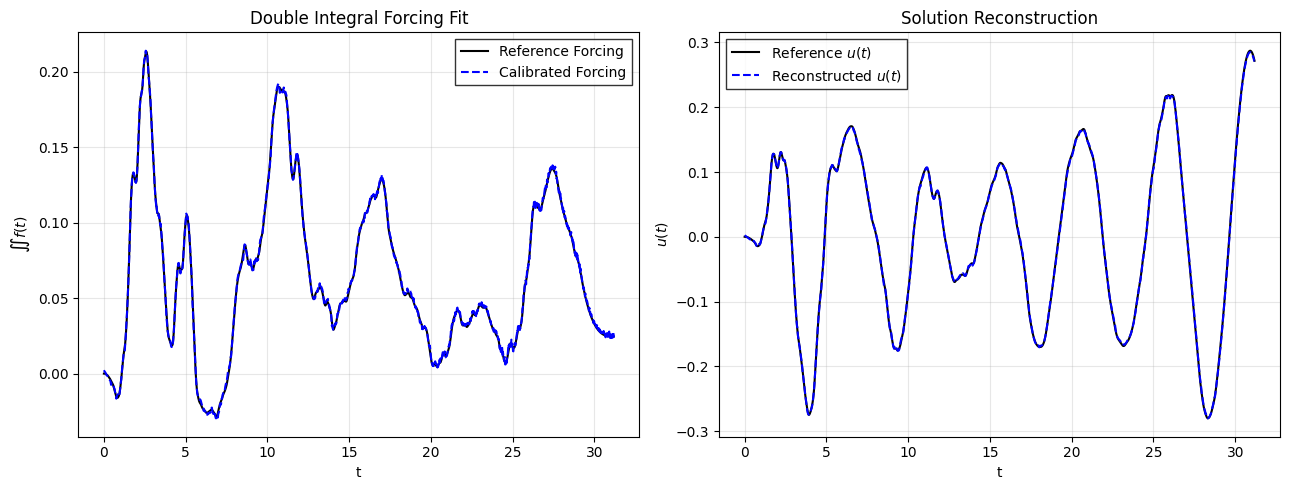


Model Error Summary
Quantity                   Absolute MSE       Relative MSE     Relative MSE (%)
--------------------------------------------------------------------------------
Forcing F*                 1.582868e-06       2.282883e-04              0.0228%
Solution u(t)              2.521983e-06       1.472484e-04              0.0147%


In [16]:
plot_calibration(t_vals, F_star, F_hat, U_ref, U_hat)
print_errors_calibration(F_hat,F_star,U_hat,U_ref)

# Testing Parameters

In [17]:
TRAIN_FRAC = 0.8  # fraction of grid points used for training
holder_value = .2
reg_lambda = 1e-5
norm_eps=norm_eps

sig_depth_predict = 8
retrain_iters_predict = 5

sig_depth_rolling = 8
retrain_iters_rolling = 5

use_normalization = True



#Train / Test Split
N_train = int(N * TRAIN_FRAC)
N_test  = N - N_train

# Training slice: first N_train points (contiguous, causal split)
t_train  = t_vals[:N_train]
t_test   = t_vals[N_train:]
f_train  = F_vals[:N_train]     # raw forcing, not F_star
f_test   = F_vals[N_train:]


print(f"Total grid points : {N}")
print(f"Train points      : {N_train}  (x in [{float(t_train[0]):.3f}, {float(t_train[-1]):.3f}])")
print(f"Test  points      : {N_test}   (x in [{float(t_test[0]):.3f},  {float(t_test[-1]):.3f}])")

Total grid points : 1560
Train points      : 1248  (x in [0.000, 24.940])
Test  points      : 312   (x in [24.960,  31.180])


## Prediction and retrain

In [18]:
import time

# ---- prediction with periodic retraining ----
if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

u_pred_full, f_pred_full = solve_signature_kernel_predict_retrain(
    t_train=t_train,
    t_test=t_test,
    f_train=f_train,
    f_test=f_test,
    k1=m,
    k2=c,
    k3=k,
    ua=0.0,
    upa=0.0,
    depth=sig_depth_predict,
    normalize=use_normalization,
    reg=reg_lambda,
    retrain_every=retrain_iters_predict,
    norm_eps=norm_eps,
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start_time
print(f"time for direct prediction and retrain method: {elapsed:.3f} seconds")

# ---- prediction with periodic retraining and t lift----
if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

u_pred_full_tlift, f_pred_full_tlift = solve_signature_kernel_predict_retrain(
    t_train=t_train,
    t_test=t_test,
    f_train=f_train,
    f_test=f_test,
    k1=m,
    k2=c,
    k3=k,
    ua=0.0,
    upa=0.0,
    depth=sig_depth_predict,
    normalize=use_normalization,
    reg=reg_lambda,
    retrain_every=retrain_iters_predict,
    use_tlift=True,
    holder_value=holder_value,
    norm_eps=norm_eps,
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start_time
print(f"time for direct prediction and retrain method, tlift: {elapsed:.3f} seconds")



final forcing loss (train+test, last beta): 4.265e-01
time for direct prediction and retrain method: 7.843 seconds
final forcing loss (train+test, last beta): 4.650e-01
time for direct prediction and retrain method, tlift: 46.188 seconds


# Evaluate

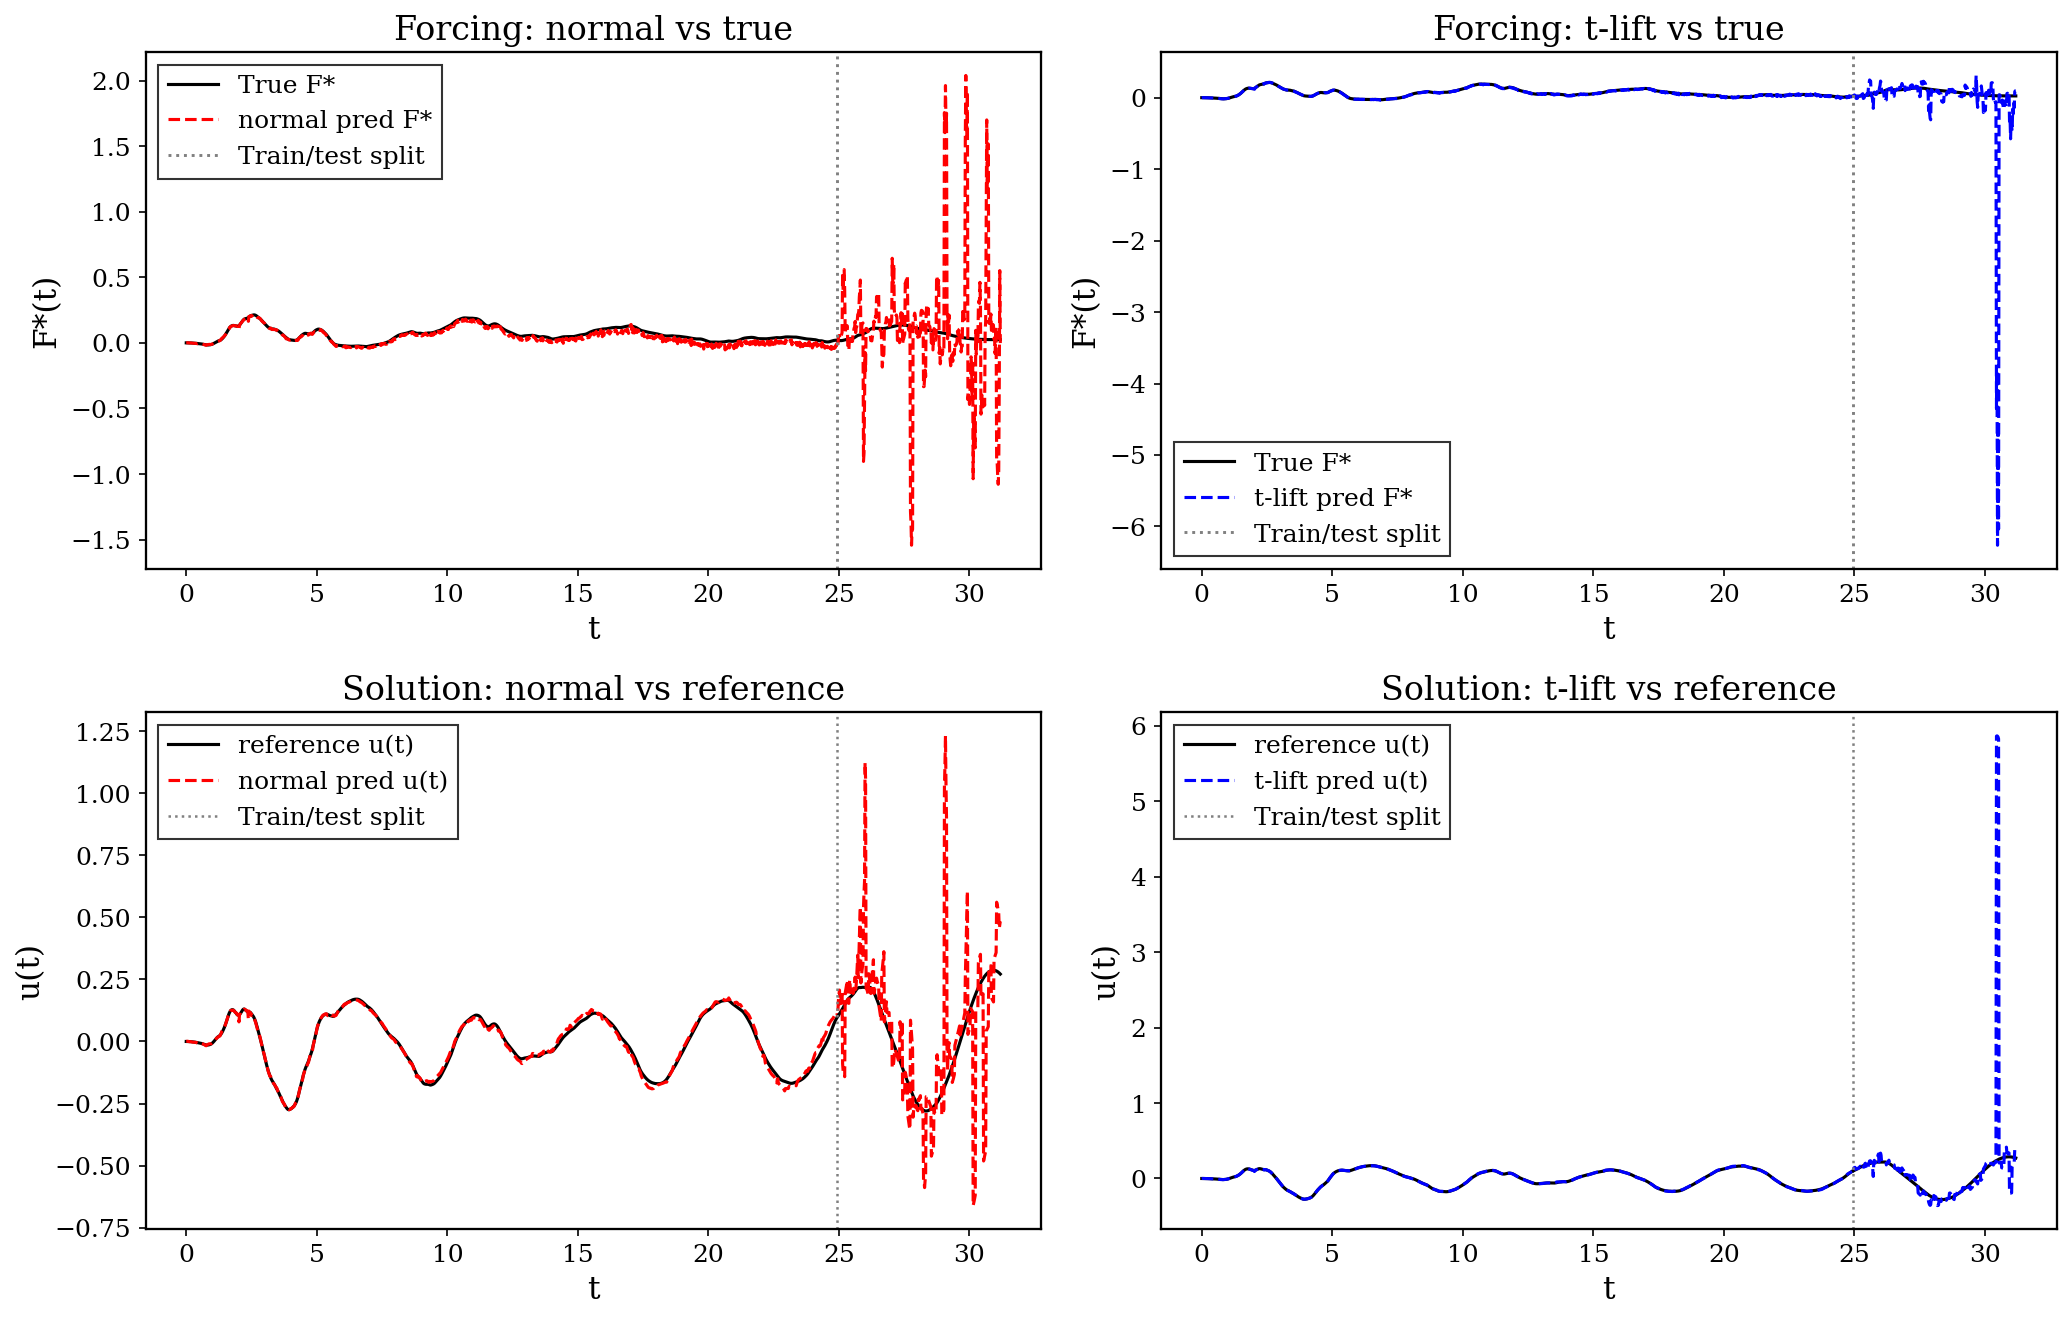


                                   Normal           t-lift  % Improvement
------------------------------------------------------------------------
Training forcing               8.9427e-02       3.3741e-03         96.23%
Training solution              1.3993e-02       3.5809e-04         97.44%
------------------------------------------------------------------------
Testing forcing                3.3467e+01       6.4124e+01        -91.60%
Testing solution               1.7206e+00       1.3788e+01       -701.33%
------------------------------------------------------------------------
Train+Test forcing             6.6168e+00       1.2543e+01        -89.56%
Train+Test solution            7.5153e-01       5.9588e+00       -692.89%


In [19]:
# 2x2 plots
plot_normal_vs_tlift(
    t_vals, TRAIN_FRAC,
    u_pred_full, f_pred_full,
    u_pred_full_tlift, f_pred_full_tlift,
    U_ref, F_star
)

# Relative MSE table
print_normal_vs_tlift(
    t_vals, TRAIN_FRAC,
    u_pred_full, f_pred_full,
    u_pred_full_tlift, f_pred_full_tlift,
    U_ref, F_star
)

## Rolling Retrain

In [20]:
## Rolling Retrain
import time

if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

u_pred_full_rolling, f_pred_full_rolling = solve_signature_kernel_rolling_retrain(
    t_train=t_train, t_test=t_test,
    f_train=f_train, f_test=f_test,
    k1=m, k2=c, k3=k,
    ua=0.0, upa=0.0,
    depth=sig_depth_rolling, normalize=use_normalization,
    reg=reg_lambda, retrain_every=retrain_iters_rolling,
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start_time
print(f"time for rolling prediction and retrain method: {elapsed:.3f} seconds")

if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

u_pred_full_tlift_rolling, f_pred_full_tlift_rolling = solve_signature_kernel_rolling_retrain(
    t_train=t_train, t_test=t_test,
    f_train=f_train, f_test=f_test,
    k1=m, k2=c, k3=k,
    ua=0.0, upa=0.0,
    depth=sig_depth_rolling, normalize=use_normalization,
    reg=reg_lambda, retrain_every=retrain_iters_rolling,
    use_tlift=True,
    holder_value=holder_value
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start_time
print(f"time for rolling prediction and retrain method, tlift: {elapsed:.3f} seconds")


final forcing loss (train+test, rolling): 7.597e-11
time for rolling prediction and retrain method: 23.635 seconds
final forcing loss (train+test, rolling): 4.755e-13
time for rolling prediction and retrain method, tlift: 37.204 seconds


# Results

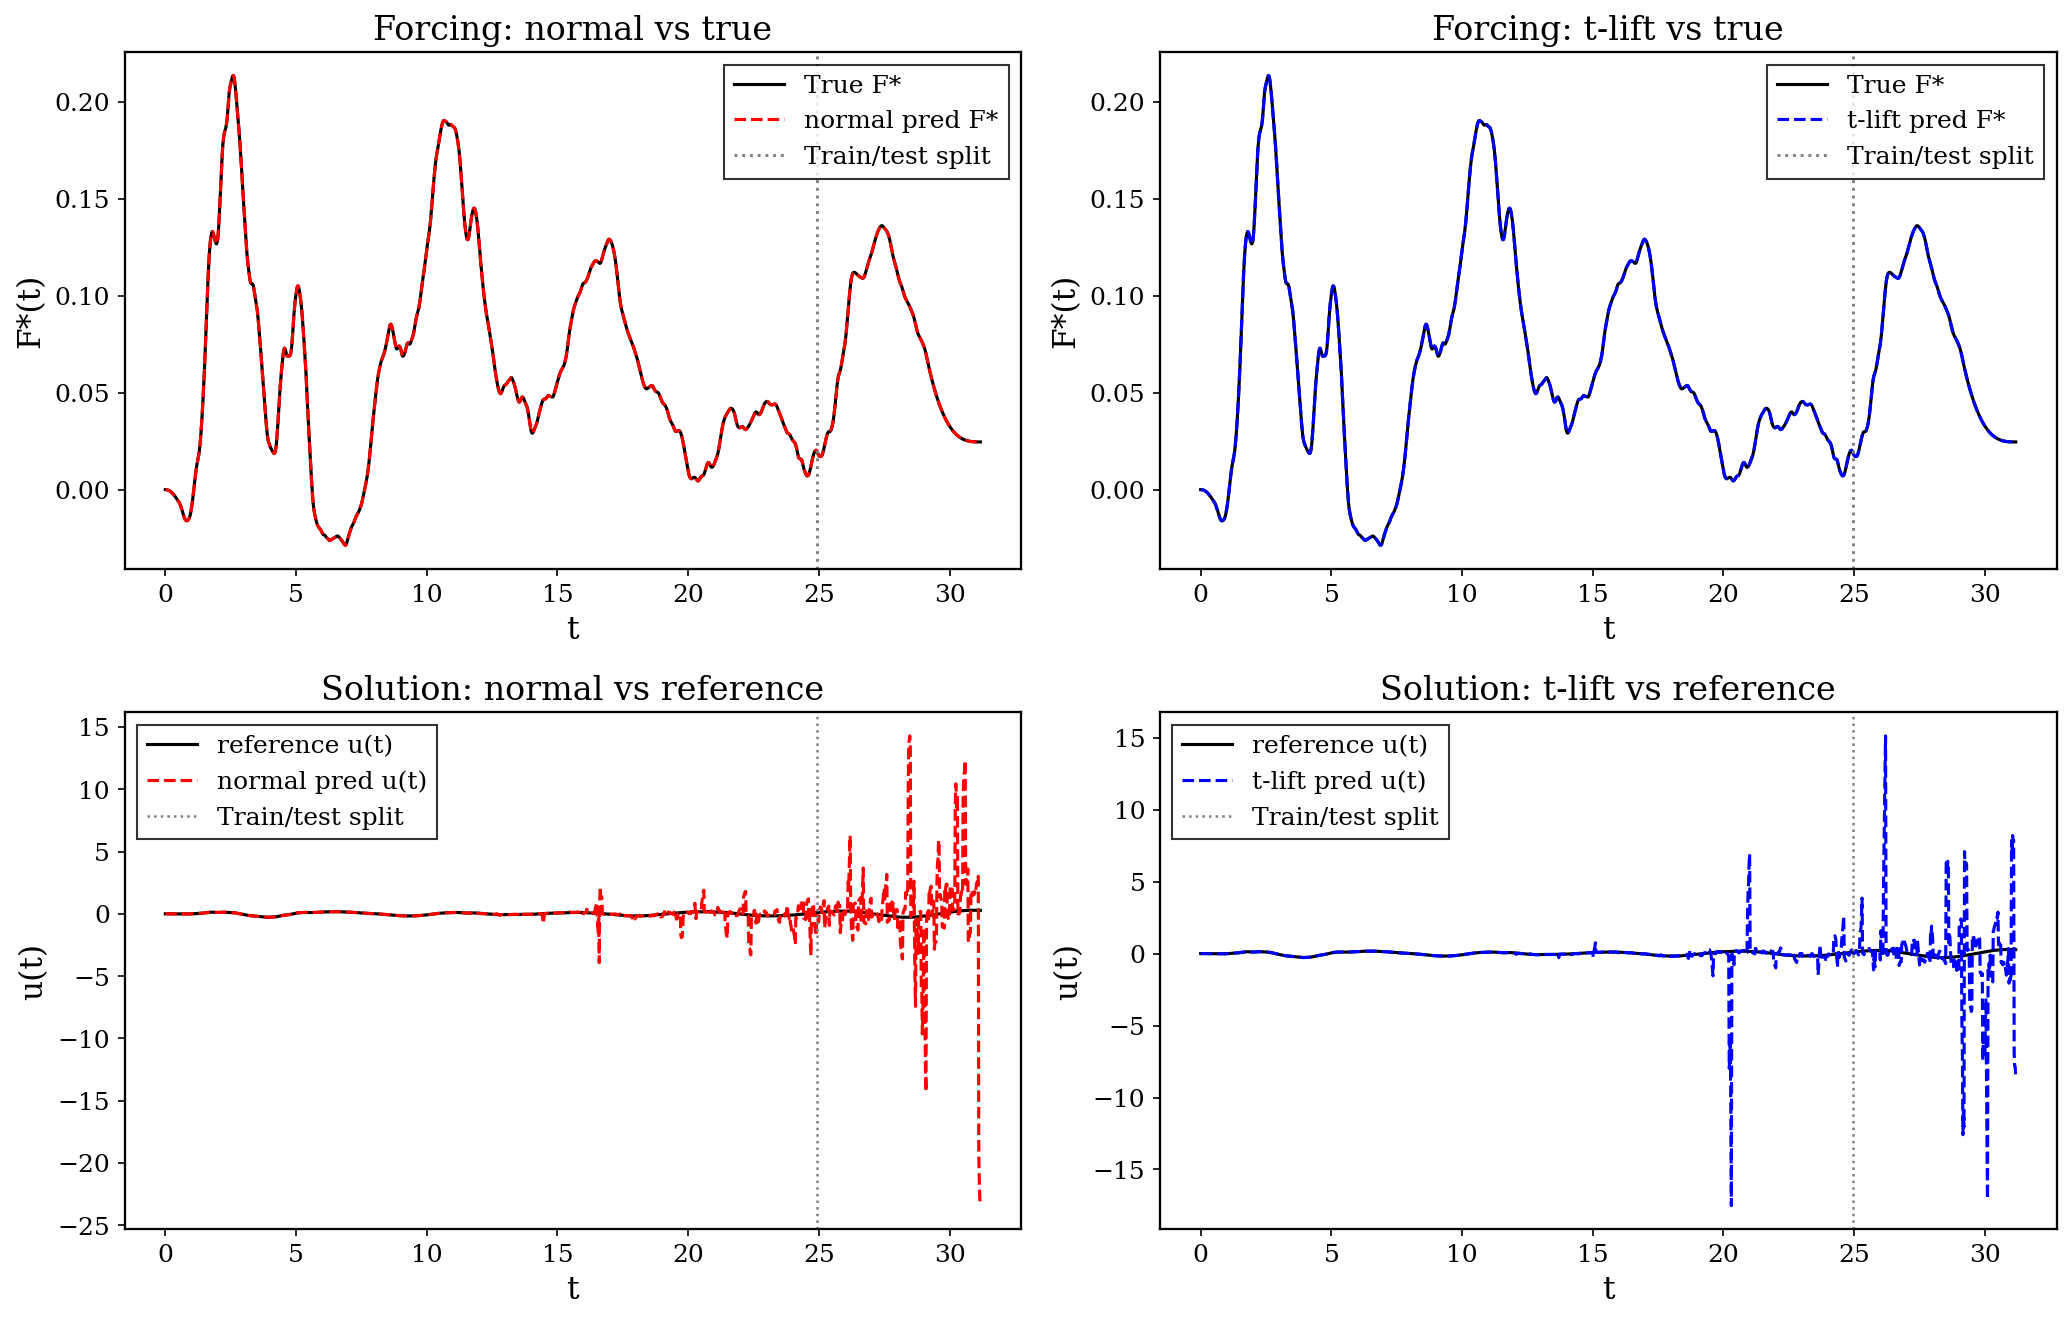


                                   Normal           t-lift  % Improvement
------------------------------------------------------------------------
Training forcing               1.3620e-08       8.5259e-11         99.37%
Training solution              1.2872e+01       4.9991e+01       -288.35%
------------------------------------------------------------------------
Testing forcing                1.7892e-27       1.7888e-27          0.02%
Testing solution               4.5651e+02       2.7003e+02         40.85%
------------------------------------------------------------------------
Train+Test forcing             1.0956e-08       6.8585e-11         99.37%
Train+Test solution            2.0460e+02       1.4508e+02         29.09%


In [21]:
plot_normal_vs_tlift(
    t_vals, TRAIN_FRAC,
    u_pred_full_rolling, f_pred_full_rolling,
    u_pred_full_tlift_rolling, f_pred_full_tlift_rolling,
    U_ref, F_star
)
print_normal_vs_tlift(
    t_vals, TRAIN_FRAC,
    u_pred_full_rolling, f_pred_full_rolling,
    u_pred_full_tlift_rolling, f_pred_full_tlift_rolling,
    U_ref, F_star
)

# Compare

Method                              Split     Forcing Rel MSE   Solution Rel MSE
--------------------------------------------------------------------------------
Predict-Retrain (normal)            Train          8.9427e-02         1.3993e-02
                                    Test           3.3467e+01         1.7206e+00
                                    All            6.6168e+00         7.5153e-01
--------------------------------------------------------------------------------
Predict-Retrain (t-lift)            Train          3.3741e-03         3.5809e-04
                                    Test           6.4124e+01         1.3788e+01
                                    All            1.2543e+01         5.9588e+00
--------------------------------------------------------------------------------
Rolling-Retrain (normal)            Train          1.3620e-08         1.2872e+01
                                    Test           1.7892e-27         4.5651e+02
                            

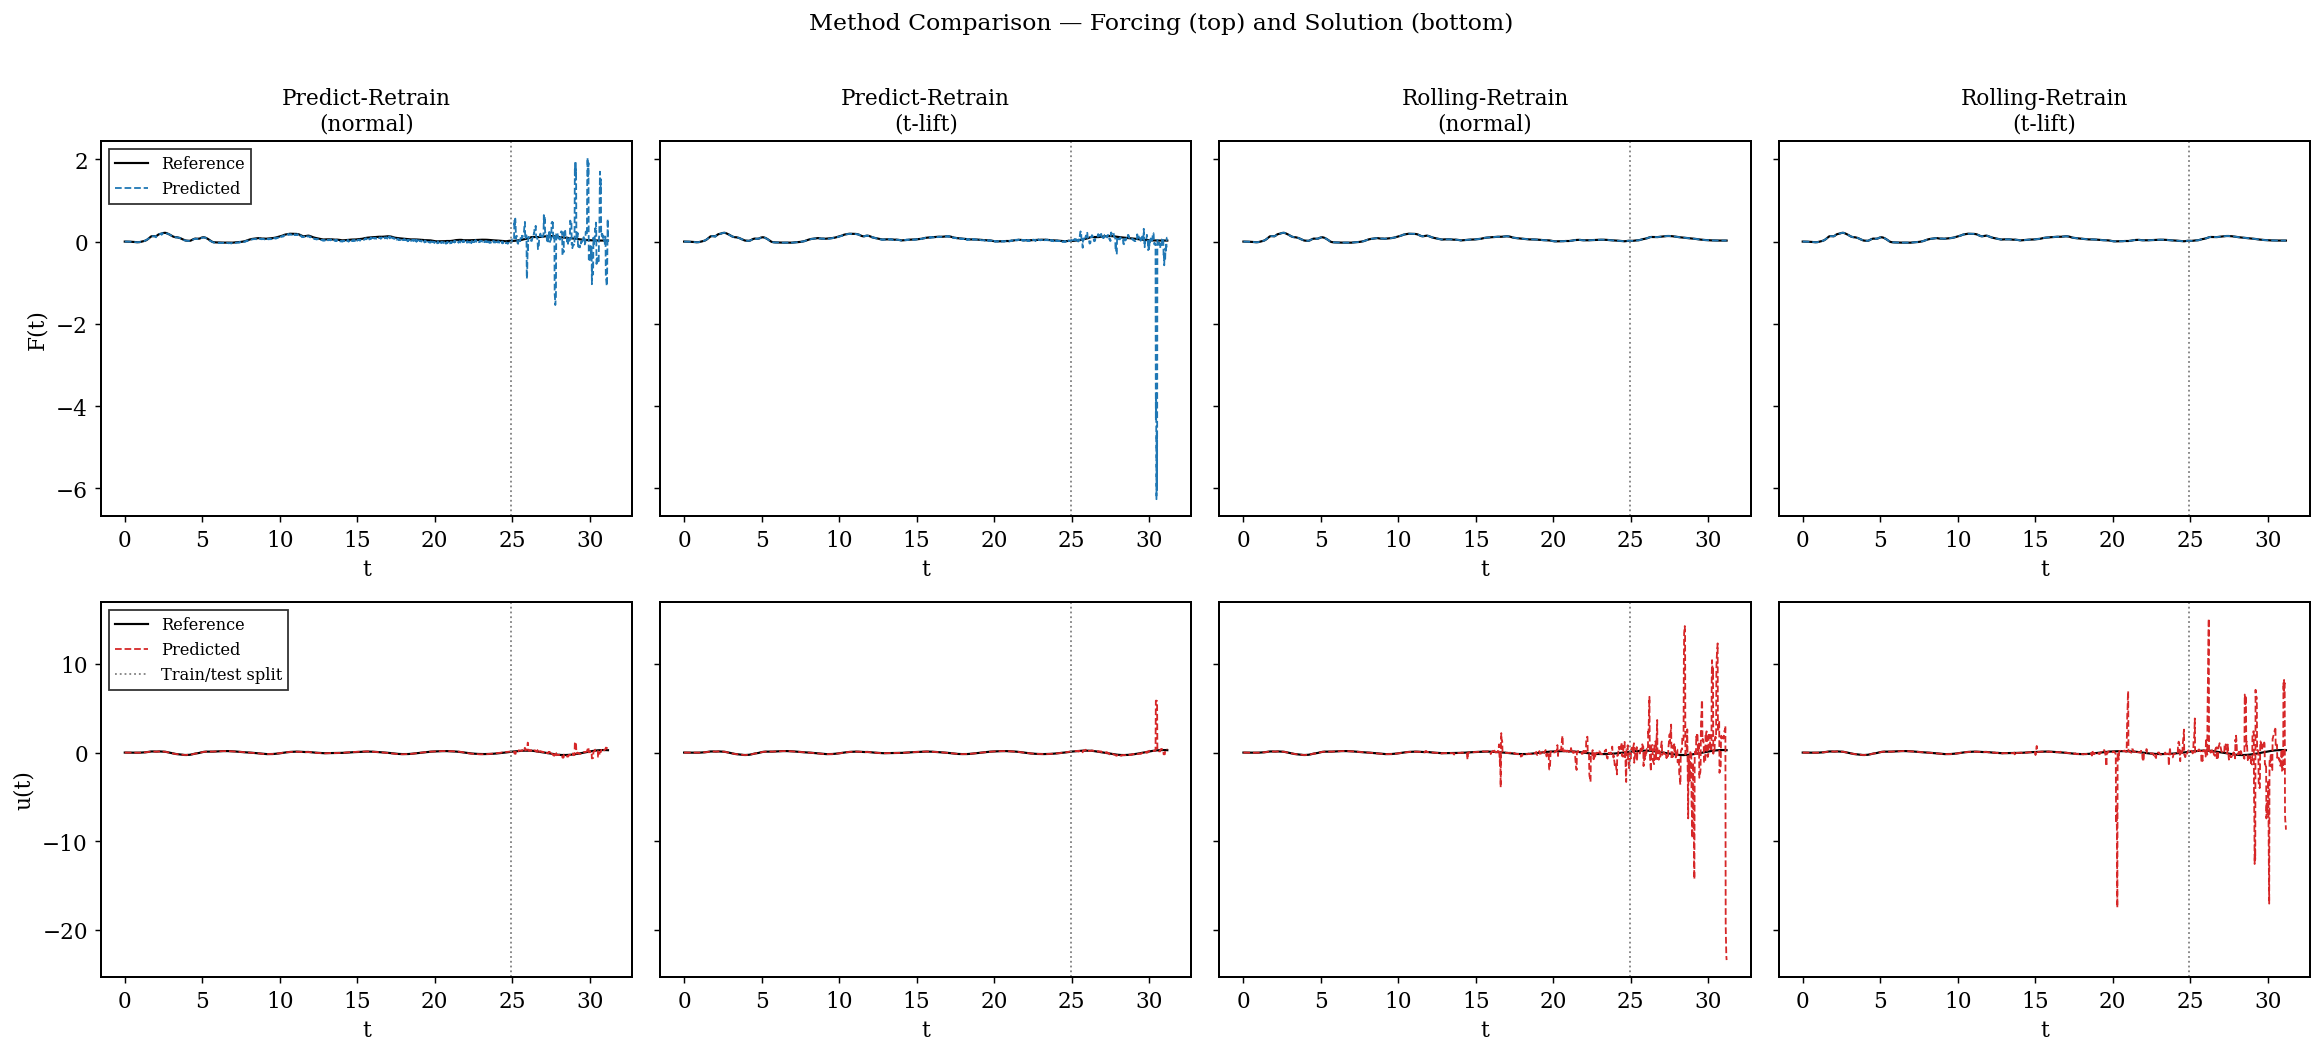

In [22]:
# --- Call both ---
print_method_comparison(
    t_vals, TRAIN_FRAC,
    f_pred_full, u_pred_full,
    f_pred_full_tlift, u_pred_full_tlift,
    f_pred_full_rolling, u_pred_full_rolling,
    f_pred_full_tlift_rolling, u_pred_full_tlift_rolling,
    F_star, U_ref
)

plot_method_comparison(
    t_vals, TRAIN_FRAC,
    f_pred_full, u_pred_full,
    f_pred_full_tlift, u_pred_full_tlift,
    f_pred_full_rolling, u_pred_full_rolling,
    f_pred_full_tlift_rolling, u_pred_full_tlift_rolling,
    F_star, U_ref
)